In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load data
df = pd.read_csv('../data/q3_retail_promotions.csv')

# 2. Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 3. Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [2]:
# 1. Sort by date
df = df.sort_values('transaction_date')

# 2. Manual Split (No shuffling)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(['items_sold', 'transaction_date', 'store_id'], axis=1)
y_train = train_df['items_sold']
X_test = test_df.drop(['items_sold', 'transaction_date', 'store_id'], axis=1)
y_test = test_df['items_sold']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 960, Test size: 240


Why Random Split is Inappropriate:
Random splitting creates Data Leakage. In time-series data, patterns evolve over time (trends and seasonality). If we use a random split, the model might learn from a transaction on Dec 31st to predict a sale on Jan 1st. A temporal split ensures we are testing the model's ability to forecast into a future it has never seen.

In [3]:
# Define column types
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = ['year', 'month', 'day_of_week', 'is_weekend', 'is_festival', 'competition_density', 'is_month_end']

# Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])


--- Linear Regression ---
RMSE: 27.13
MAE: 21.07


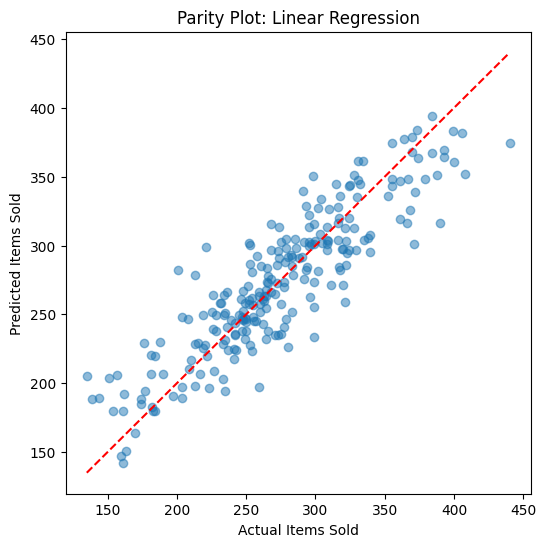


--- Random Forest ---
RMSE: 31.31
MAE: 25.11


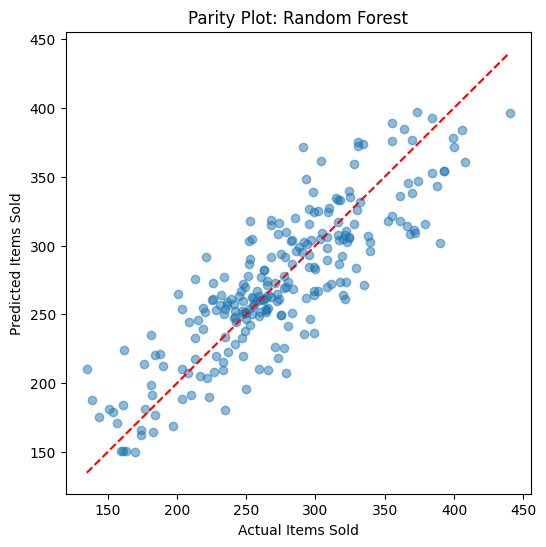

In [4]:
# Define the models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    # Create and fit pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    
    # Parity Plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.show()

In [5]:
# Extract the Random Forest model from its pipeline
rf_model = pipeline.named_steps['regressor']

# Get feature names from the transformer
# (Note: OneHotEncoder creates new names for categories)
cat_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Pair names with importance
importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)

print("\nTop 5 Most Influential Features:")
print(importances.head(5))


Top 5 Most Influential Features:
is_festival            0.173579
store_size_small       0.167192
location_type_urban    0.108581
day_of_week            0.088328
is_weekend             0.066540
dtype: float64
